<a href="https://colab.research.google.com/github/aggretzukxo/neutron-star-eos-density-solver/blob/main/neutron_star.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def drhobdrb(rb,rhob,Mb,a):
    res=-((rhob+a*(rhob-1.0))*(Mb+4.0*np.pi*rb**3*a*(rhob-1.0)))/(a*rb**2*(1.0-(2.0*Mb/rb)))
    return res

def dMbdrb(rb,rhob):
    res=4.0*np.pi*rb**2*rhob
    return res

In [ ]:
def RK4(funrhob,funMb,xn,ynr,ynM,h,a):
    k1r=h*funrhob(xn,ynr,ynM,a)
    k1M=h*funMb(xn,ynr)

    k2r=h*funrhob(xn+0.5*h,ynr+0.5*k1r,ynM+0.5*k1M,a)
    k2M=h*funMb(xn+0.5*h,ynr+0.5*k1r)


    k3r=h*funrhob(xn+0.5*h,ynr+0.5*k2r,ynM+0.5*k2M,a)
    k3M=h*funMb(xn+0.5*h,ynr+0.5*k2r)


    k4r=h*funrhob(xn+h,ynr+k3r,ynM+k3M,a)
    k4M=h*funMb(xn+h,ynr+k3r)

    ynpl1r=ynr+(k1r+2.0*k2r+2.0*k3r+k4r)/6.0
    ynpl1M=ynM+(k1M+2.0*k2M+2.0*k3M+k4M)/6.0
    xnpl1=xn+h
    return xnpl1,ynpl1r,ynpl1M


/tmp/ipykernel_5494/3383622352.py:41: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1,figsize=(8,6),dpi=300)
/tmp/ipykernel_5494/3383622352.py:44: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(2,figsize=(8,6),dpi=300)


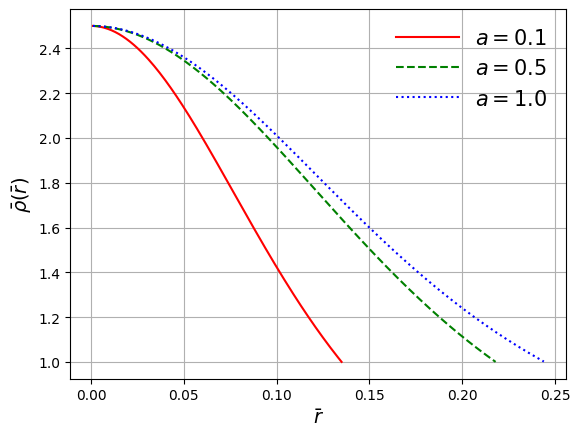

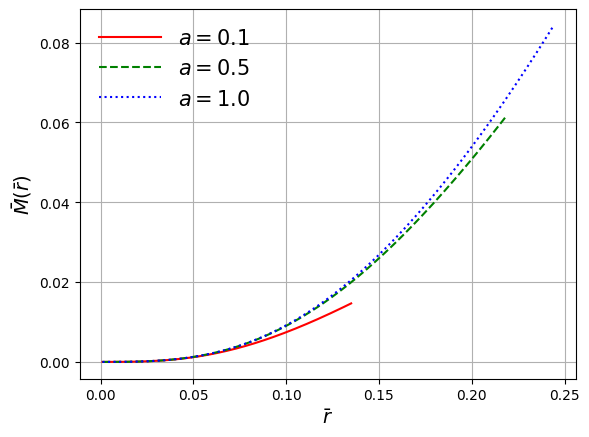

In [ ]:
cases=[[0.1,'r-'],[0.5,'g--'],[1.0,'b:']]


for i,[a,style] in enumerate(cases,0):
    rb=0.001
    rhobc=2.5
    rhob=rhobc
    rhobf=1.0
    Mb=(4.0/3.0)*np.pi*rb**3*rhobc
    h=0.001

    x=[]
    y=[]
    z=[]

    while rhob>=rhobf:
        x.append(rb)
        y.append(rhob)
        z.append(Mb)
        rb,rhob,Mb=RK4(drhobdrb,dMbdrb,rb,rhob,Mb,h,a)

    plt.figure(1)
    plt.plot(x,y,style,label=f"$a=${a}")

    plt.figure(2)
    plt.plot(x,z,style,label=f"$a=${a}")

plt.figure(1)
plt.legend(loc='upper right',fontsize=15,frameon=False, handlelength=3.,framealpha=1)
plt.xlabel('$\\bar{r}$',fontsize=14)
plt.ylabel('$\\bar{\\rho}(\\bar{r})$',fontsize=14)
plt.grid()

plt.figure(2)
plt.legend(loc='upper left',fontsize=15,frameon=False, handlelength=3.,framealpha=1)
plt.xlabel('$\\bar{r}$',fontsize=14)
plt.ylabel('$\\bar{M}(\\bar{r})$',fontsize=14)
plt.grid()


plt.figure(1,figsize=(8,6),dpi=300)
plt.savefig('rhobar.pdf',dpi=300)

plt.figure(2,figsize=(8,6),dpi=300)
plt.savefig('Mbar.pdf',dpi=300)


plt.show()

/tmp/ipykernel_5494/417631839.py:27: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1,figsize=(8,6),dpi=300)


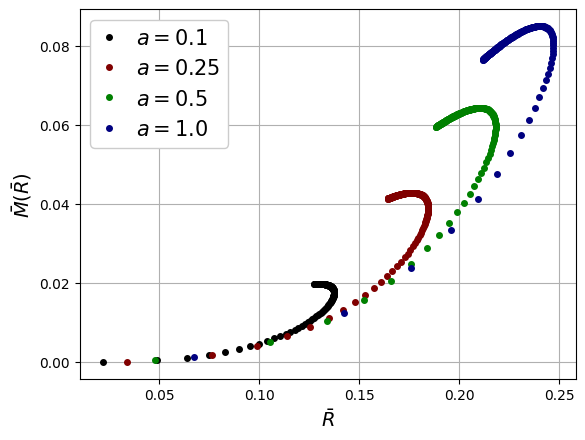

In [ ]:
cases=[[0.1,(0.,0,0)],[0.25,(0.5,0,0)],[0.5,(0,0.5,0)],[1.0,(0,0,0.5)]]

for i,[a,mycolor] in enumerate(cases,0):
  rhobc=np.linspace(1.01,10,200)
  rhobf=1.0
  h=0.0001
  R=[]
  M=[]
  for j in range(len(rhobc)):
    rb=0.001
    x=[]
    y=[]
    rhob=rhobc[j]
    Mb=(4.0/3.0)*np.pi*rb**3*rhobc[j]
    while rhob>=rhobf:
      x.append(rb)
      y.append(Mb)
      rb,rhob,Mb=RK4(drhobdrb,dMbdrb,rb,rhob,Mb,h,a)
    R.append(x[-1])
    M.append(y[-1])
  plt.plot(R,M,'.',color=mycolor,markersize=8,label=f"$a={a}$")

plt.legend(loc='upper left',fontsize=15,frameon=True, handlelength=1.,framealpha=1)
plt.xlabel('$\\bar{R}$',fontsize=14)
plt.ylabel('$\\bar{M}(\\bar{R})$',fontsize=14)
plt.grid()
plt.figure(1,figsize=(8,6),dpi=300)
plt.savefig('MR.pdf',dpi=300)
plt.show()
